In [1]:
import os
import traceback
import numpy as np

# Import all components from the TAOG analysis package
from GPhIon import (
    load_simulation_data,
    CoordinateProcessor,
    TracerPropertyAnalyzer,
    VibrationAnalyzer,
    AmorphousSiteFinder,
    SiteAnalyzerMDA,
    JumpDiffusivityAnalyzer,
    CollectiveJumpAnalyzer,
    RDFAnalyzer,
    plot_taog_density,
    VanHoveAnalyzer,
    MigrationPathwayPlotter
)

print("="*80)
print("TAOG (Time-Averaged Occupancy Grid) Analysis")
print("="*80)

# --- 1. Define Parameters ---
project_folder = '/media/ram/ext_disk/proj_mof/dp_data/test_package'
dump_filename = 'pure_400.lammpstrj'
dump_filepath = os.path.join(project_folder, dump_filename)

type_to_element = {1: 'S', 2: 'F', 3: 'O', 4: 'N', 5: 'C', 6: 'Li', 7: 'Co', 8: 'H'}
diffusing_element = 'Li'
timestep_ps = 0.1  # Picosecond timestep 450:0.1,  400: 2.0

# Analysis parameters
density_grid_resolution = 100
output_data_path = os.path.join(project_folder, "analysis_output")
diffusion_dimensionality = 3
ion_charge_z = 1.0

# Collective jump parameters
experimental_coll_dist = 6.0  # Angstroms
experimental_coll_steps = None  # Auto-calculate from jump frequency

# Ensure output directory exists
os.makedirs(output_data_path, exist_ok=True)

if not os.path.exists(dump_filepath):
    raise FileNotFoundError(f"CRITICAL ERROR: Trajectory file not found at '{dump_filepath}'")

# --- 2. Load Trajectory Data ---
print("\n🔄 Loading simulation data...")
sim_data_obj = load_simulation_data(
    dump_file=dump_filepath,
    type_to_element=type_to_element,
    diff_elem=diffusing_element,
    dt_ps=timestep_ps,
    temperature = 450
)
print(f"✅ Loaded trajectory with {sim_data_obj.nr_steps} frames")
print(f"   📊 {sim_data_obj.nr_diffusing} diffusing {diffusing_element} atoms out of {sim_data_obj.nr_atoms} total")

# --- 3. Calculate Fractional Coordinates and Displacement ---
print("\n🔄 Calculating coordinates and displacement...")
coord_processor = CoordinateProcessor()
sim_data_obj = coord_processor.frac_and_disp(sim_data_obj)
print("✅ Coordinate processing complete")

# --- 4. Calculate Tracer Properties (from MSD) ---
print("\n🔄 Analyzing tracer properties from MSD...")
tracer_analyzer = TracerPropertyAnalyzer(sim_data_obj)
tracer_results = tracer_analyzer.calculate_tracer_properties(
    diffusion_dim=diffusion_dimensionality,
    z_ion=ion_charge_z
)
print("✅ Tracer property analysis complete")

TAOG (Time-Averaged Occupancy Grid) Analysis

🔄 Loading simulation data...
--- Stage 1: Reading LAMMPS Trajectory ---


/home/ram/software/miniconda3/lib/python3.12/site-packages/MDAnalysis/topology/LAMMPSParser.py:637: UserWarning: Guessed all Masses to 1.0
  warnings.warn('Guessed all Masses to 1.0')


DEBUG: Trajectory loaded with 1501 frames.
✅ Loaded trajectory with 1501 frames
   📊 48 diffusing Li atoms out of 3328 total

🔄 Calculating coordinates and displacement...
DEBUG: CoordinateProcessor instance created.
DEBUG: Calculating fractional coordinates and displacement...
DEBUG: Displacement calculation finished.
✅ Coordinate processing complete

🔄 Analyzing tracer properties from MSD...

--- Stage: Analyzing Tracer Properties (MSD) ---
-------------------------------------------
Calculating tracer diffusion and conductivity based on:
3 dimensional diffusion, and an ion with a charge of 1.0
Tracer diffusivity determined to be (in m^2/s): 6.4006e-11
Tracer conductivity determined to be (in Siemens/meter): 0.3086
-------------------------------------------
✅ Tracer property analysis complete


Saved vibrational amplitudes: output/vibrational_amplitudes.dat
Saved per-atom frequencies: output/per_atom_frequencies.dat
Saved frequency spectrum: output/frequency_spectrum.dat
Saved summary statistics: output/vibration_summary.dat
Saved histogram data: output/amplitude_histogram_data.dat
Saved Gaussian fit: output/amplitude_gaussian_fit.dat


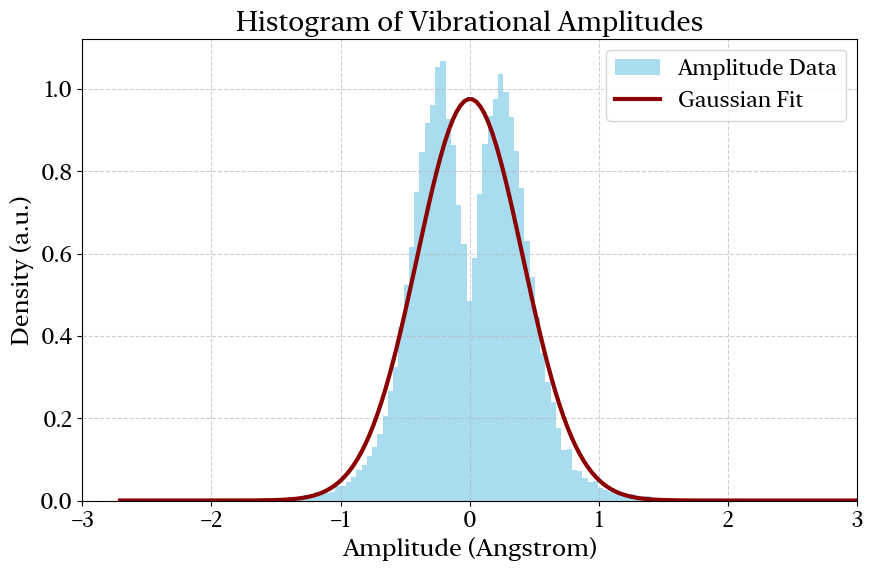

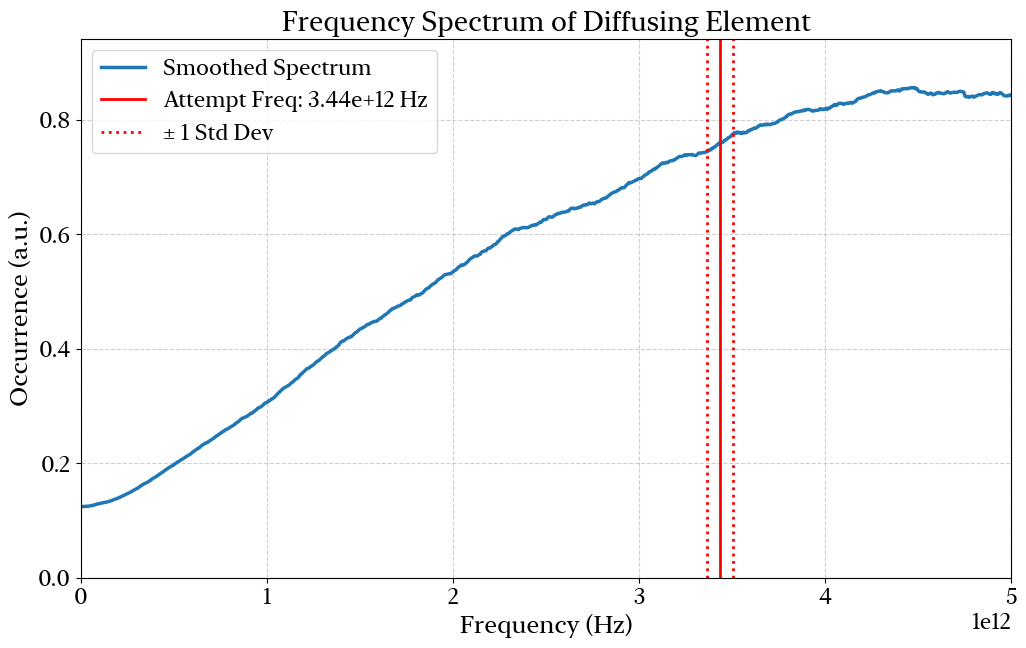

In [7]:
# Create vibration analyzer instance
vib_analyzer = VibrationAnalyzer()

# Run vibration analysis without plotting but save data
attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
    sim_data_obj, show_pics=False, save_data=True, output_dir="output"
)

# Get detailed data for custom plotting
vib_data = vib_analyzer.get_vibration_data_only(sim_data_obj)

# Plot 1: Custom amplitude histogram using the built-in method
vib_analyzer.plot_amplitude_histogram_only(
    vib_data,
    bins=150,  # More bins
    colors={'hist': 'skyblue', 'fit': 'darkred'},
    xlim=(-3.0, 3.0),  # Custom x-limits
    output_file="custom_amplitude_hist.png"
)

# Plot 2: Custom frequency spectrum using the built-in method
vib_analyzer.plot_frequency_spectrum_only(
    vib_data,
    xlim=(0, 5e12),  # Custom frequency range
    smooth_window=75,  # More smoothing
    output_file="custom_frequency_spectrum.png"
)



🔄 Analyzing vibrational properties...
Saved vibrational amplitudes: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/vibrational_amplitudes.dat
Saved per-atom frequencies: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/per_atom_frequencies.dat
Saved frequency spectrum: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/frequency_spectrum.dat
Saved summary statistics: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/vibration_summary.dat
Saved histogram data: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/amplitude_histogram_data.dat
Saved Gaussian fit: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/amplitude_gaussian_fit.dat


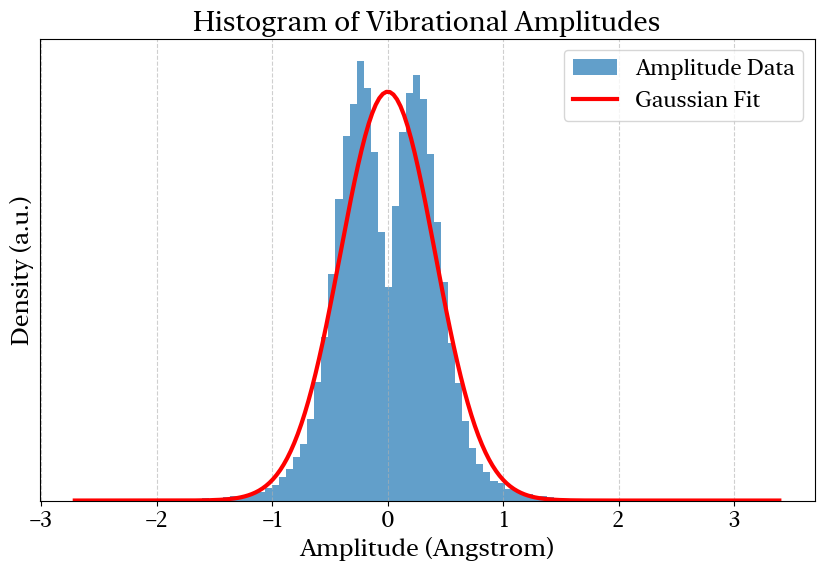

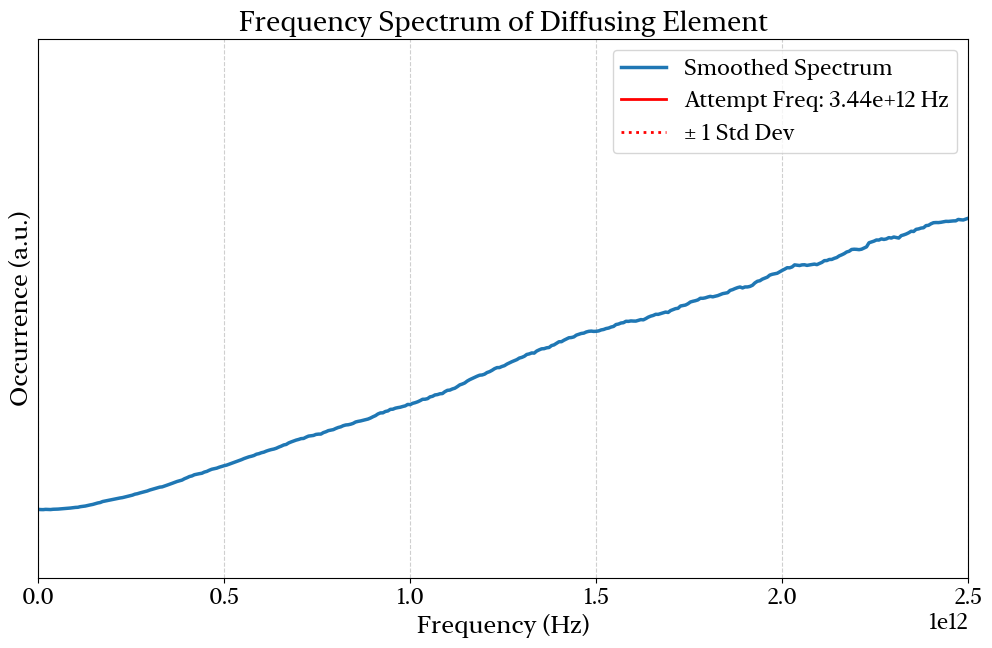

✅ Vibrational analysis complete with data saved
✅ Vibrational analysis complete

🔄 Discovering sites using TAOG method...

--- Stage 2: Discovering Sites from Time-Averaged Occupancy Grid ---
DEBUG: Building 100x100x100 occupancy grid...
DEBUG: Saved grid edges to /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/occupancy_grid_edges.npy
DEBUG: Using density threshold of 110.87 to find peaks.
DEBUG: Found 48 potential sites.
DEBUG: Saved discovered site coordinates to /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/discovered_sites_cart.npy
✅ Site discovery complete: 48 sites found

🔄 Generating TAOG density visualization...
Plot saved to /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/taog_density_plot.png
✅ TAOG visualization saved

🔄 Analyzing jumps between sites...
DEBUG: Using site radius for jump analysis: 2.1816 Å


  0%|          | 0/1501 [00:00<?, ?it/s]

DEBUG: Jump analysis complete with occupancy tracking
       Total jumps detected: 564
       Average site occupancies: [0.99866755 1.         0.94803464 0.99933378 1.         1.
 1.         0.92538308 0.99933378 0.71685543 1.         0.99933378
 0.99933378 1.         0.5976016  0.4023984  0.99800133 0.99933378
 1.         1.         1.         0.43171219 0.56828781 0.99600266
 0.88407728 1.         1.         1.         0.99800133 1.
 0.99600266 1.         1.         0.99933378 1.         1.
 0.99733511 0.99133911 1.         1.         0.9733511  0.52098601
 0.47901399 1.         1.         1.         1.03197868 0.88207861]
✅ Jump analysis complete: 564 jumps detected

🔄 Calculating jump diffusivity...

--- Stage 4: Post-Processing Jumps for Diffusivity Analysis ---
Jump diffusivity calculated assuming 3D diffusion.
 - Total simulation time: 1.50e-10 s
 - Number of diffusing atoms: 48
 - Resulting Jump Diffusivity (m^2/s): 1.0056e-10
Saved jump distances: /media/ram/ext_disk/proj_mof/

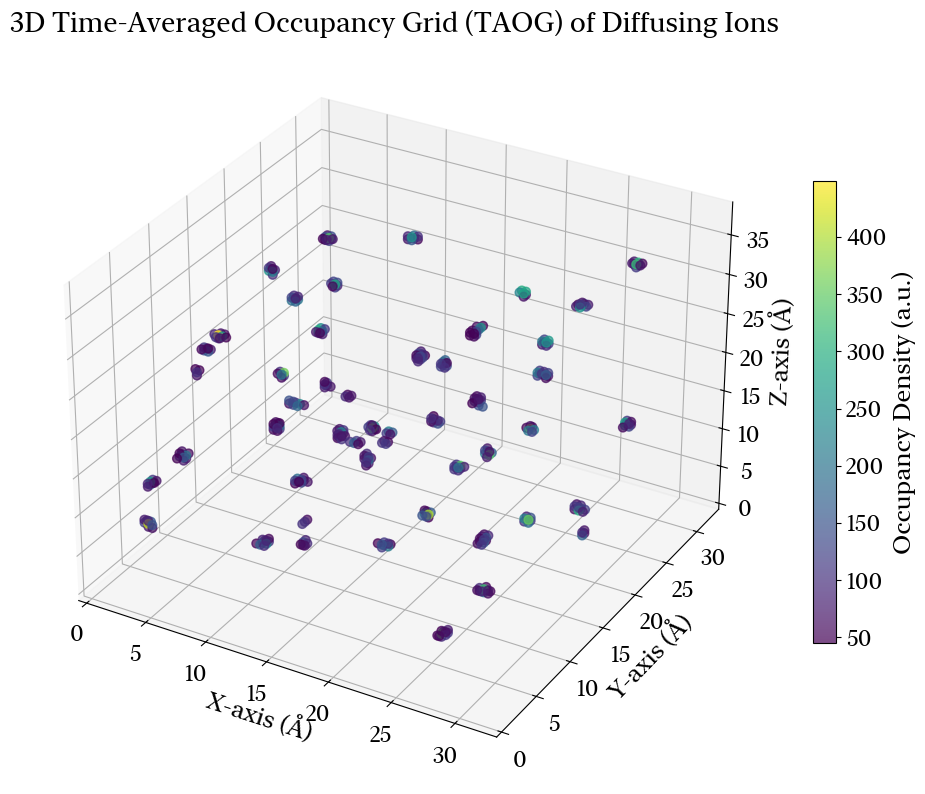

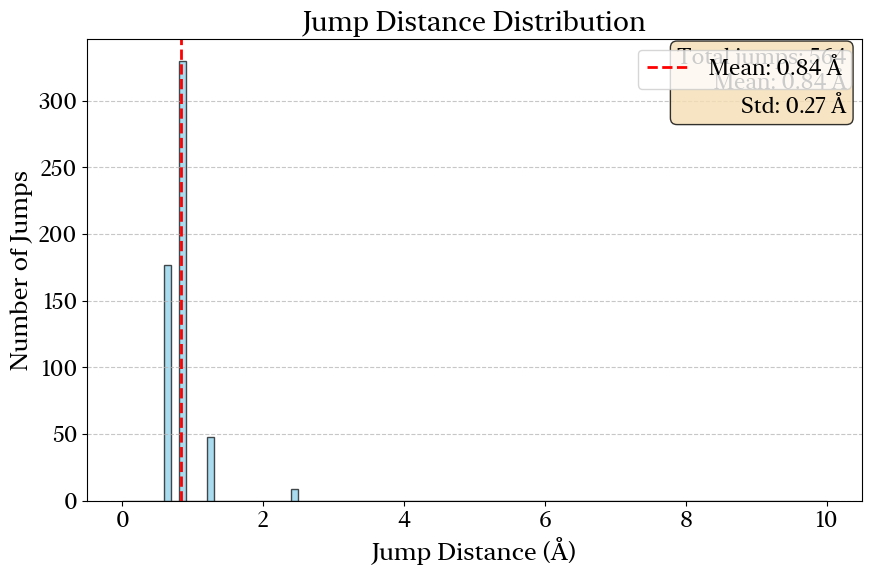

Saved analysis summary: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/jump_analysis_summary.dat
✅ Jump diffusivity calculation complete with data saved

🔄 Analyzing collective jump behavior...

--- Stage: Analyzing Collective Jumps ---
INFO: Using calculated time window for collective jumps: 3 steps.
INFO: Using spatial window for collective jumps: 6.0 Å.
Total number of jumps: 564
Number of possibly collective jump pairs found: 0
✅ Collective jump analysis complete


In [ ]:
# --- 5. Calculate Vibrational Properties and Jump Frequency ---
print("\n🔄 Analyzing vibrational properties...")
# vib_analyzer = VibrationAnalyzer()
# attempt_freq, vibration_amp, std_freq = vib_analyzer.vibration_properties(
#     sim_data_obj, 
#     show_pics=True,
#     save_data=True,  # Enable data saving
#     output_dir=output_data_path  # Save to your analysis directory
# )

# # Store results in sim_data object
# sim_data_obj.attempt_freq = attempt_freq
# sim_data_obj.vibration_amp = vibration_amp
# sim_data_obj.std_attempt_freq = std_freq
# print("✅ Vibrational analysis complete with data saved")

# # Store results in sim_data object
# sim_data_obj.attempt_freq = attempt_freq
# sim_data_obj.vibration_amp = vibration_amp
# sim_data_obj.std_attempt_freq = std_freq
# print("✅ Vibrational analysis complete")

# --- 6. Discover Sites from TAOG Density Grid ---
print("\n🔄 Discovering sites using TAOG method...")
site_finder = AmorphousSiteFinder(
    sim_data=sim_data_obj,
    grid_resolution=density_grid_resolution,
    save_path=output_data_path
)
discovered_sites_cartesian = site_finder.find_sites_from_density()

if discovered_sites_cartesian.size == 0:
    raise RuntimeError("❌ No sites were discovered. Check your parameters.")

print(f"✅ Site discovery complete: {len(discovered_sites_cartesian)} sites found")

# --- 7. Visualize TAOG Density Grid ---
print("\n🔄 Generating TAOG density visualization...")
try:
    # Load the saved density grid and edges
    grid_file = os.path.join(output_data_path, 'occupancy_density_grid.npy')
    edges_file = os.path.join(output_data_path, 'occupancy_grid_edges.npy')
    
    if os.path.exists(grid_file) and os.path.exists(edges_file):
        density_grid = np.load(grid_file)
        edges = np.load(edges_file, allow_pickle=True)
        
        plot_output = os.path.join(output_data_path, 'taog_density_plot.png')
        plot_taog_density(density_grid, edges, threshold_ratio=0.1, output_file=plot_output)
        print("✅ TAOG visualization saved")
    else:
        print("⚠️  TAOG density files not found for visualization")
except Exception as e:
    print(f"⚠️  Could not generate TAOG visualization: {e}")

# --- 8. Analyze Jumps Between Discovered Sites ---
print("\n🔄 Analyzing jumps between sites...")
diffusing_atoms_group = sim_data_obj.universe.select_atoms(f"element {diffusing_element}")

jump_analysis = SiteAnalyzerMDA(
    diffusing_atom_group=diffusing_atoms_group,
    site_coordinates_cart=discovered_sites_cartesian
)
jump_analysis.run(verbose=True)

num_jumps_found = len(jump_analysis.results.all_trans) if hasattr(jump_analysis.results, 'all_trans') else 0
print(f"✅ Jump analysis complete: {num_jumps_found} jumps detected")

# --- 9. Calculate Jump Diffusivity ---
print("\n🔄 Calculating jump diffusivity...")
jump_diffusivity_val = 0.0
if num_jumps_found > 0:
    diffusivity_analyzer = JumpDiffusivityAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian
    )
    jump_diffusivity_val = diffusivity_analyzer.calculate_jump_properties(
        show_plot=True,
        save_data=True,  # Enable data saving
        output_dir=output_data_path  # Save to your analysis directory
    )
    
    # Also save comprehensive summary
    diffusivity_analyzer.save_jump_summary(jump_diffusivity_val, output_data_path)
    
    print("✅ Jump diffusivity calculation complete with data saved")
else:
    print("⚠️  No jumps found - skipping jump diffusivity calculation")

# --- 10. Analyze Collective Jumps ---
print("\n🔄 Analyzing collective jump behavior...")
collective_results = None
if num_jumps_found > 0:
    collective_analyzer = CollectiveJumpAnalyzer(
        sim_data=sim_data_obj,
        jump_analysis_results=jump_analysis.results,
        site_coordinates_cart=discovered_sites_cartesian,
        coll_dist=experimental_coll_dist,
        coll_steps_manual=experimental_coll_steps
    )
    collective_results = collective_analyzer.analyze()
    print("✅ Collective jump analysis complete")
else:
    print("⚠️  No jumps found - skipping collective jump analysis")

# --- 11. Optional: Calculate RDFs ---
# print("\n🔄 Calculating Radial Distribution Functions...")
# try:
#     effective_site_radius = getattr(jump_analysis, 'site_radius', 2.0)
#     rdf_analyzer = RDFAnalyzer(
#         sim_data=sim_data_obj,
#         site_coordinates_cart=discovered_sites_cartesian,
#         site_radius=effective_site_radius
#     )
#     rdf_data = rdf_analyzer.calculate_rdfs(show_plot=True)
#     print("✅ RDF analysis complete")
# except Exception as e:
#     print(f"⚠️  RDF analysis failed: {e}")


🛤️  Creating enhanced migration pathways with time-based probability...
Plotted 14 migration pathways


/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr/new_17_jul_25/taog_analysis/GPhIon/visualization/mig_path_plotter.py:636: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


Enhanced 3D migration plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/enhanced_migration_pathways.png


/home/ram/software/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


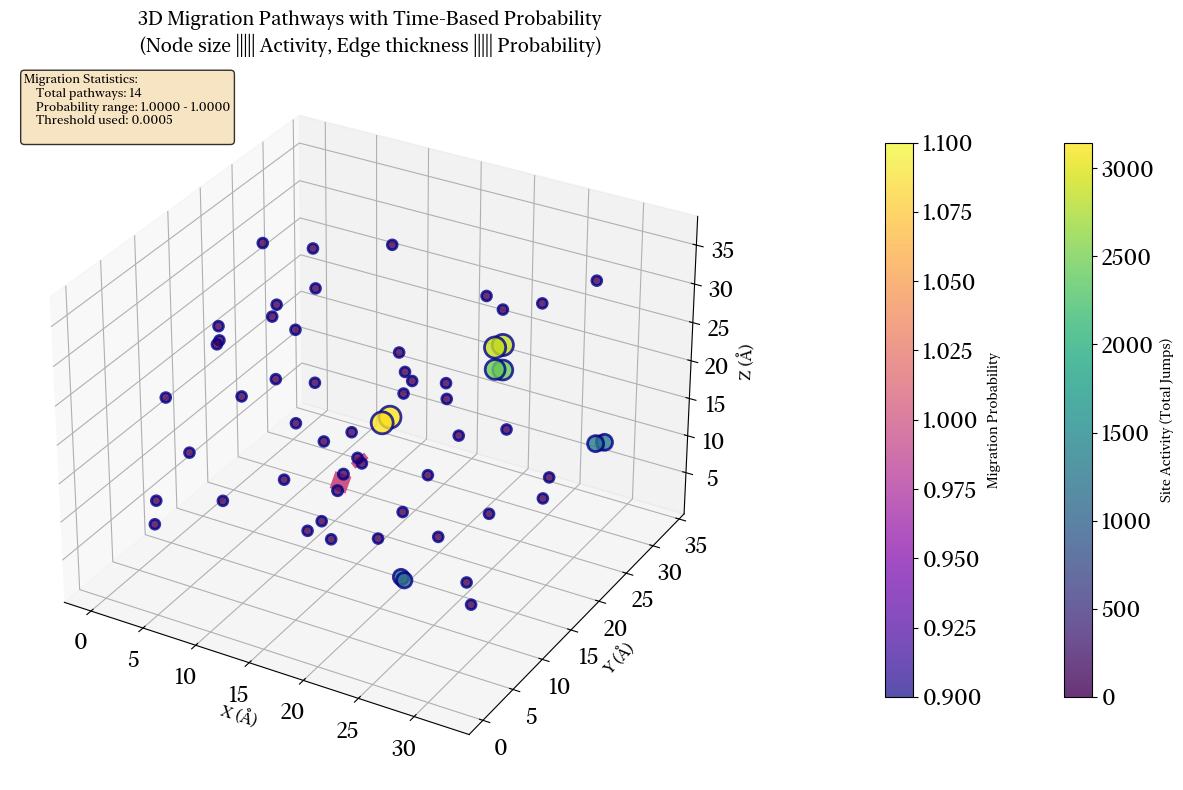

✅ Enhanced migration pathway visualization complete!
Migration Probability Analysis:
  Total jumps: 10971
  Active sites: 14/60
  Max probability: 0.1439
  Normalization: total
Migration matrix statistics:
  Non-zero connections: 14
  Max probability: 0.143925
  Min non-zero probability: 0.000456


In [3]:
# --- Enhanced Migration Pathway Analysis ---
print("\n🛤️  Creating enhanced migration pathways with time-based probability...")

if num_jumps_found > 0:
    from GPhIon import MigrationPathwayPlotter
    
    # Create enhanced migration plotter
    migration_plotter = MigrationPathwayPlotter()
    
    # Add the enhanced methods to your existing class
    # (You can modify the class directly or inherit from it)
    
    # Plot with multiple threshold approaches
    migration_plotter.plot_enhanced_3d_migration_pathways(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.0005,  # Very low threshold
        use_time_weighting=True,
        connection_threshold=1,   # Show connections with even 1 jump
        edge_width_scale=12,
        output_file=f"{output_data_path}/enhanced_migration_pathways.png"
    )
    
    print("✅ Enhanced migration pathway visualization complete!")
    
    # Also try the standard approach with lower threshold
    migration_results = migration_plotter.calculate_migration_probabilities(
        jump_analysis.results.all_trans, 
        discovered_sites_cartesian,
        normalization='total'  # Try different normalization
    )
    
    print(f"Migration matrix statistics:")
    print(f"  Non-zero connections: {np.count_nonzero(migration_results['probability_matrix'])}")
    print(f"  Max probability: {np.max(migration_results['probability_matrix']):.6f}")
    print(f"  Min non-zero probability: {np.min(migration_results['probability_matrix'][migration_results['probability_matrix'] > 0]):.6f}")

else:
    print("⚠️  No jumps found - skipping migration pathway analysis")


Migration Probability Analysis:
  Total jumps: 10971
  Active sites: 14/60
  Max probability: 1.0000
  Normalization: outgoing
Plotted 3540 migration pathways
3D migration pathway plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/probabilistic_hopping_paths.png


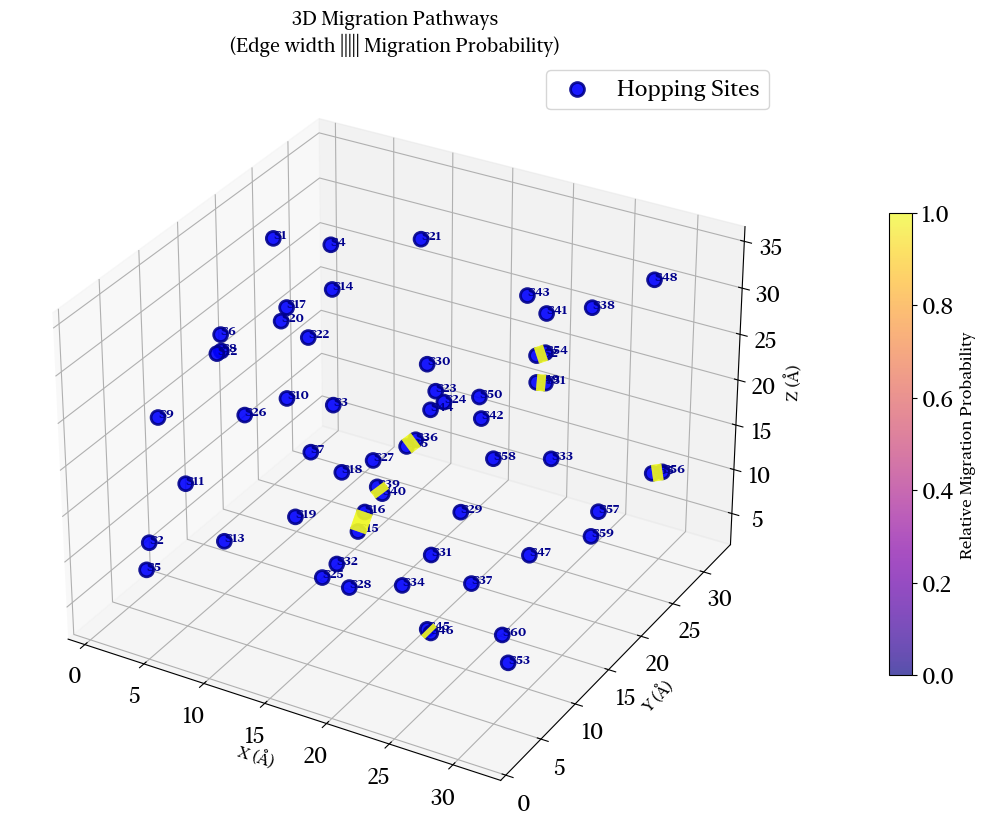

In [6]:
# Calculate migration probabilities from your jump data
migration_results = migration_plotter.calculate_migration_probabilities(
    jump_data=jump_analysis.results.all_trans,
    sites_cart=discovered_sites_cartesian,
    normalization='outgoing'  # Normalize by outgoing jumps per site
)

# Create 3D probabilistic pathway plot
migration_plotter.plot_3d_migration_pathways(
    sites_cart=discovered_sites_cartesian,
    probability_matrix=migration_results['probability_matrix'],
    min_probability=0.000,  # Show pathways with >1% probability
    edge_width_scale=12,   # Scale line thickness by probability
    colormap='plasma',     # Color edges by probability
    output_file=f"{output_data_path}/probabilistic_hopping_paths.png"
)


🛤️  Analyzing migration pathways with probability weighting...
🔄 Generating comprehensive migration pathway analysis...
Migration Probability Analysis:
  Total jumps: 10971
  Active sites: 14/60
  Max probability: 1.0000
  Normalization: outgoing
Plotted 14 migration pathways


/media/ram/ext_disk/proj_mof/dp_data/analysis/vf_ppr/new_17_jul_25/taog_analysis/GPhIon/visualization/mig_path_plotter.py:193: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  plt.savefig(output_file, dpi=300, bbox_inches='tight')


3D migration pathway plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/jump_output/3d_migration_pathways.png


/home/ram/software/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


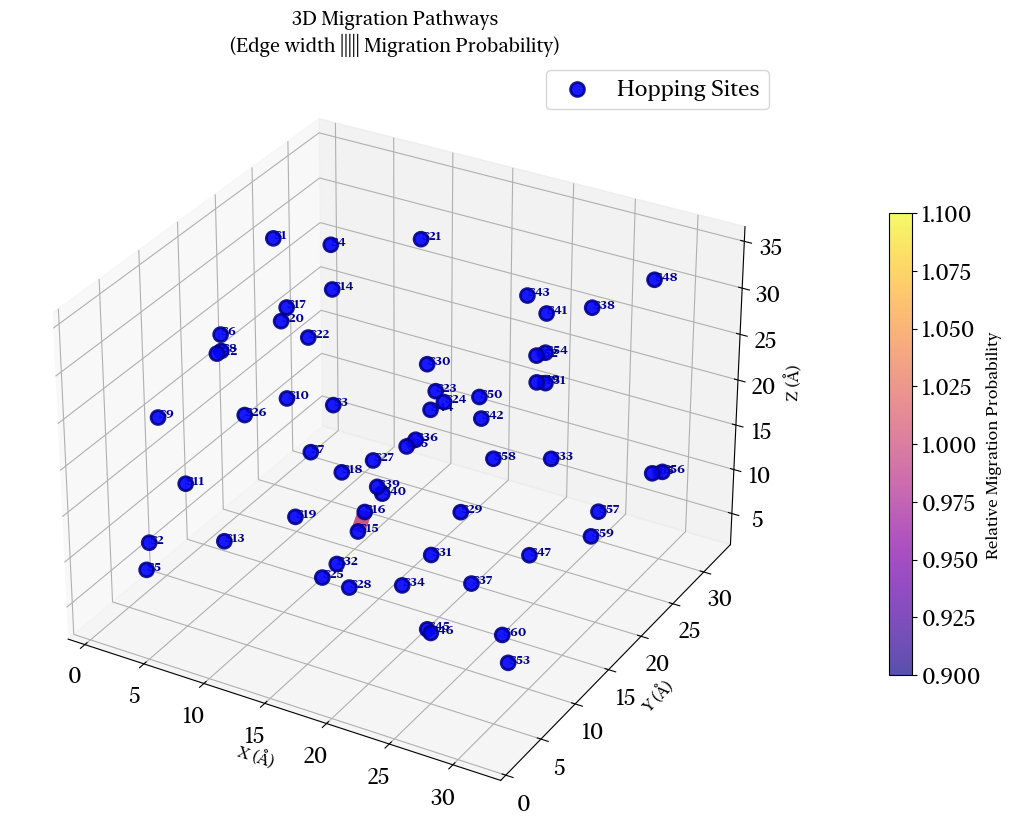

Network analysis plot saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/jump_output/migration_network.png


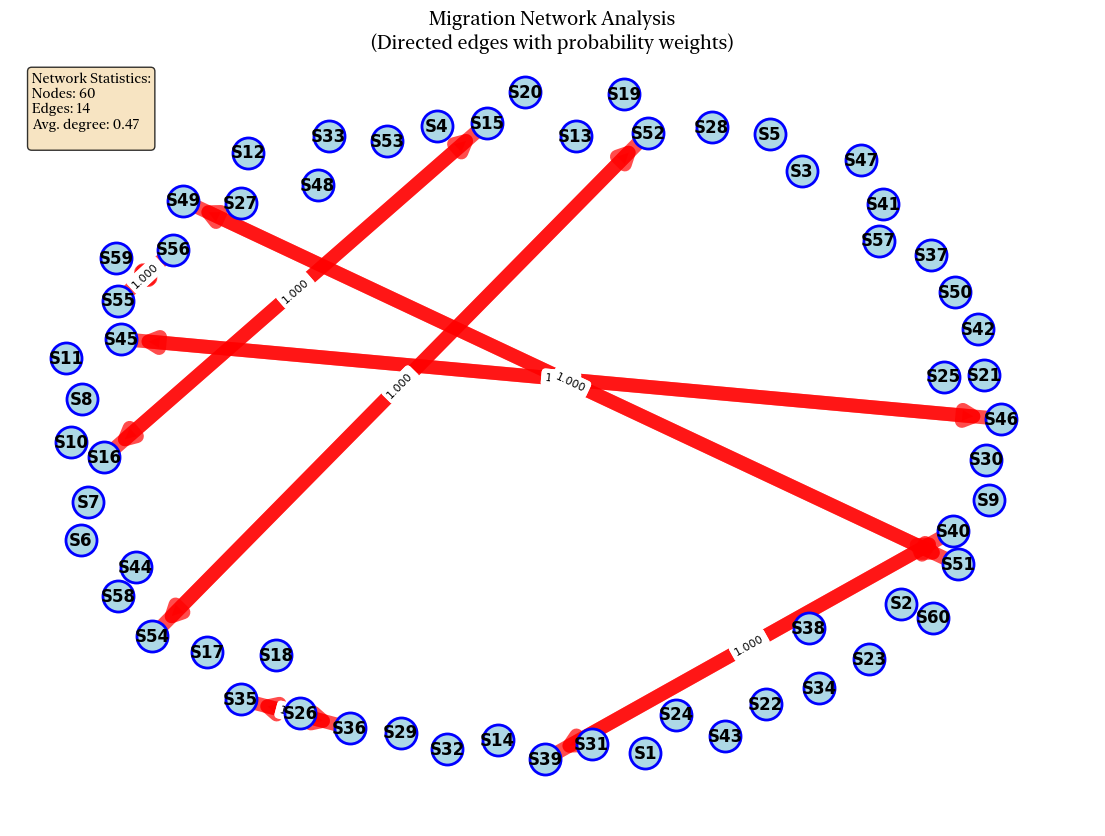


Migration Pathway Analysis:
  Active migration network: 14 sites, 14 pathways
  Most central sink (incoming): Site 15 (0.077)
  Most central source (outgoing): Site 15 (0.077)
  Most important bridge: Site 15 (0.000)
  Top migration pathways:
    1. Site 15 → Site 16: 1.0000
    2. Site 16 → Site 15: 1.0000
    3. Site 35 → Site 36: 1.0000
    4. Site 36 → Site 35: 1.0000
    5. Site 39 → Site 40: 1.0000
Migration analysis report saved: /media/ram/ext_disk/proj_mof/dp_data/test_package/analysis_output/jump_output/migration_analysis_report.txt
✅ Comprehensive migration pathway analysis complete!
✅ Migration pathway analysis complete!

🛤️  MIGRATION PATHWAY RESULTS:
   Total migration pathways:          14
   Most active source site:           Site 15
   Most active sink site:             Site 15
   Key bridge site:                   Site 15
   Highest probability pathway:       Site 15 → Site 16 (1.0000)


In [11]:
# --- 12. NEW: Migration Pathway Analysis ---
print("\n🛤️  Analyzing migration pathways with probability weighting...")

if num_jumps_found > 0:
    # from taog_analysis import MigrationPathwayPlotter
    
    migration_plotter = MigrationPathwayPlotter()
    
    # Generate comprehensive migration analysis
    migration_analysis = migration_plotter.plot_comprehensive_migration_analysis(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_probability=0.001,  # Show pathways with >2% probability
        output_dir=output_data_path
    )
    
    print("✅ Migration pathway analysis complete!")
    
    # Display key results
    prob_results = migration_analysis['migration_probabilities']
    pathway_results = migration_analysis['pathway_analysis']
    
    print(f"\n🛤️  MIGRATION PATHWAY RESULTS:")
    print(f"   Total migration pathways:          {pathway_results['total_edges']}")
    print(f"   Most active source site:           Site {pathway_results['most_central_out'][0]+1}")
    print(f"   Most active sink site:             Site {pathway_results['most_central_in'][0]+1}")
    print(f"   Key bridge site:                   Site {pathway_results['most_between'][0]+1}")
    
    if pathway_results['high_probability_edges']:
        top_pathway = pathway_results['high_probability_edges'][0]
        print(f"   Highest probability pathway:       Site {top_pathway[0]+1} → Site {top_pathway[1]+1} ({top_pathway[2]:.4f})")

else:
    print("⚠️  No jumps found - skipping migration pathway analysis")


⚡ Calculating activation energies...

--- Activation Energy Analysis ---
Activation Energy Results:
  Effective jump frequency: 7.62e+10 Hz
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 2.53e-02
  Activation Energy: 0.143 eV
                   : 13.8 kJ/mol

Calculating site-specific activation energies:
Total simulation time: 3.00e-09 s
Temperature: 450.0 K
Attempt frequency: 3.01e+12 Hz
Activation Energy Results:
  Effective jump frequency: 1.87e+11 Hz
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 6.21e-02
  Activation Energy: 0.108 eV
                   : 10.4 kJ/mol
Activation Energy Results:
  Effective jump frequency: 4.03e+11 Hz
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 1.34e-01
  Activation Energy: 0.078 eV
                   : 7.5 kJ/mol
Activation Energy Results:
  Effective jump frequency: 4.80e+11 Hz
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 1.59e-01


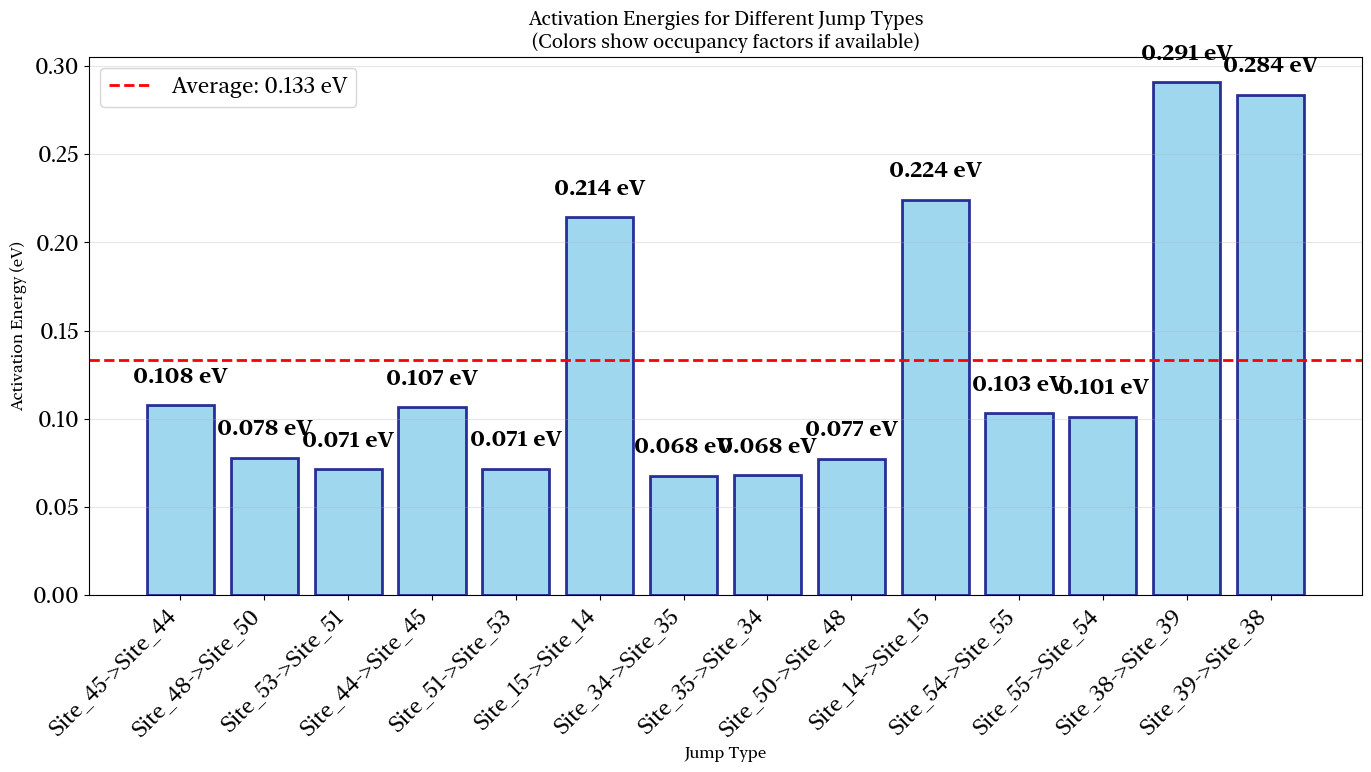

✅ Activation energy analysis complete!


In [8]:
# --- 11. Activation Energy Analysis ---
print("\n⚡ Calculating activation energies...")

if num_jumps_found > 0:
    from GPhIon import ActivationEnergyAnalyzer
    
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
    # Set temperature from filename (pure_450.lammpstrj suggests 450K)
    sim_data_obj.temperature = 450.0  # K
    
    # Overall activation energy
    total_time = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
    try:
        overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
            effective_jump_freq=effective_freq,
            attempt_freq=sim_data_obj.attempt_freq,
            temperature=sim_data_obj.temperature
        )
    except Exception as e:
        print(f"⚠️  Overall activation energy calculation failed: {e}")
        overall_activation = None
    
    # Site-specific activation energies
    try:
        site_energies = activation_analyzer.calculate_site_specific_activation_energies(
            jump_data=jump_analysis.results.all_trans,
            sites_cart=discovered_sites_cartesian,
            temperature=sim_data_obj.temperature,
            attempt_freq=sim_data_obj.attempt_freq
        )
        
        if site_energies:
            activation_analyzer.compare_activation_energies(
                site_energies,
                output_file=f"{output_data_path}/activation_energies_comparison.png"
            )
    except Exception as e:
        print(f"⚠️  Site-specific activation energy calculation failed: {e}")
        site_energies = None
else:
    overall_activation = None
    site_energies = None

print("✅ Activation energy analysis complete!")



⚡ Calculating activation energies...

--- Activation Energy Analysis ---
Validation check:
  Effective frequency: 7.62e+10 Hz
  Attempt frequency: 3.01e+12 Hz
  Frequency ratio: 0.0253
Activation Energy Results:
  Effective jump frequency: 7.62e+10 Hz
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 2.53e-02
  Activation Energy: 0.143 eV
                   : 13.8 kJ/mol
✅ Overall Activation Energy: 0.143 eV

Calculating activation energies with occupancy corrections:
Temperature: 450.0 K
Attempt frequency: 3.01e+12 Hz
Total simulation time: 3.00e-09 s
Found 14 different jump types
Applied occupancy correction: 0.0119
Activation Energy Results:
  Effective jump frequency: 1.87e+11 Hz
  Corrected jump frequency: 1.57e+13 Hz
  Occupancy factor: 0.0119
  Attempt frequency: 3.01e+12 Hz
  Temperature: 450.0 K
  Frequency ratio: 5.21e+00
  Activation Energy: -0.064 eV
                   : -6.2 kJ/mol
  Site_45->Site_44: -0.064 eV (occupancy: 0.0119)
Applied occupanc

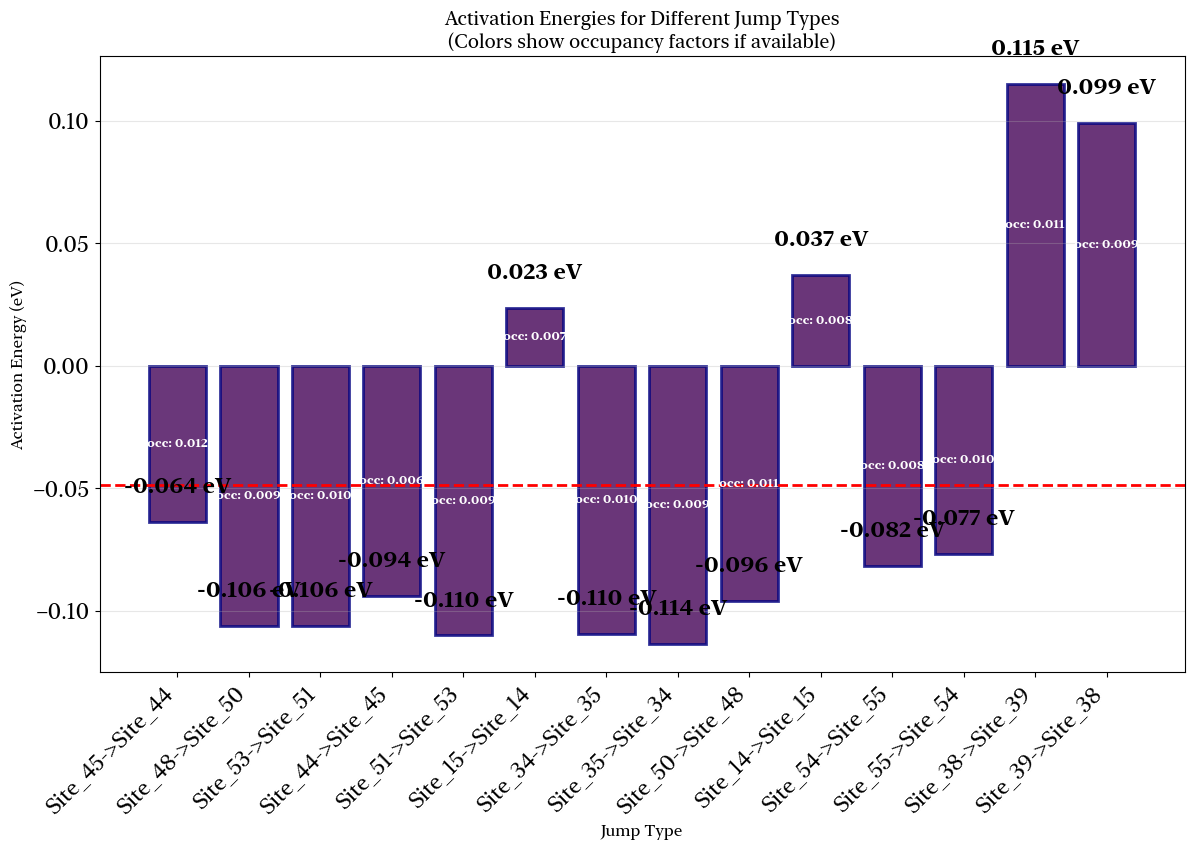

In [9]:
# Add this right after your collective jump analysis in your notebook

# --- 11. Activation Energy Analysis ---
print("\n⚡ Calculating activation energies...")

if num_jumps_found > 0:
    from GPhIon import ActivationEnergyAnalyzer
    
    # IMPORTANT: Set correct temperature from your filename
    sim_data_obj.temperature = 450.0  # K (from pure_450.lammpstrj)
    
    activation_analyzer = ActivationEnergyAnalyzer(sim_data_obj)
    
    # Method 1: Overall activation energy
    total_time = sim_data_obj.total_time
    effective_freq = num_jumps_found / (sim_data_obj.nr_diffusing * total_time)
    
    print(f"Validation check:")
    print(f"  Effective frequency: {effective_freq:.2e} Hz")
    print(f"  Attempt frequency: {sim_data_obj.attempt_freq:.2e} Hz")
    print(f"  Frequency ratio: {effective_freq/sim_data_obj.attempt_freq:.4f}")
    
    if effective_freq/sim_data_obj.attempt_freq < 1.0:
        try:
            overall_activation = activation_analyzer.calculate_activation_energy_from_frequencies(
                effective_jump_freq=effective_freq,
                attempt_freq=sim_data_obj.attempt_freq,
                temperature=sim_data_obj.temperature
            )
            print(f"✅ Overall Activation Energy: {overall_activation['activation_energy_eV']:.3f} eV")
        except Exception as e:
            print(f"⚠️  Could not calculate overall activation energy: {e}")
    else:
        print("⚠️  Frequency ratio ≥ 1.0 - check temperature and frequency calculations")
    
    # Method 2: Site-specific with occupancy corrections
    try:
        # Use the enhanced jump_analyzer with occupancy tracking
        site_energies = activation_analyzer.calculate_activation_energies_with_occupancy(
            jump_analysis_results=jump_analysis,  # Pass the main object, not .results
            sites_cart=discovered_sites_cartesian,
            temperature=sim_data_obj.temperature
        )
        
        if site_energies:
            activation_analyzer.compare_activation_energies(
                site_energies,
                output_file=f"{output_data_path}/activation_energies_comparison.png"
            )
            
            # Generate comprehensive report
            activation_analyzer.generate_activation_energy_report(
                site_energies,
                output_file=f"{output_data_path}/activation_energy_report.txt"
            )
            
            print(f"✅ Site-specific activation energies calculated for {len(site_energies)} jump types")
        
    except Exception as e:
        print(f"⚠️  Site-specific activation energy calculation failed: {e}")

else:
    print("⚠️  No jumps found - skipping activation energy analysis")

print("✅ Activation energy analysis complete!")


In [10]:
# --- Save Occupancy and Jump Data ---
print("\n💾 Saving occupancy and jump data to files...")

# Create output directory
output_data_path = f"{output_data_path}/jump_output"
os.makedirs(output_data_path, exist_ok=True)

# # 1. Save site occupancy data
# np.savetxt(f'{output_data_path}/site_occupancies.txt', 
#            jump_analysis.results.site_occupancies,
#            header='Site_ID Average_Occupancy(atoms)', fmt='%.6f')

# np.savetxt(f'{output_data_path}/occupancy_factors.txt', 
#            jump_analysis.results.average_occupancy_factors,
#            header='Site_ID Occupancy_Factor', fmt='%.6f')

# # 2. Save residence time statistics
# with open(f'{output_data_path}/residence_time_stats.txt', 'w') as f:
#     f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
#     for site_idx in range(jump_analysis.n_sites):
#         stats = jump_analysis.results.residence_time_stats[site_idx]
#         f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
#                 f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")

# # 3. Save jump events
# np.savetxt(f'{output_data_path}/jump_events.txt', jump_analysis.results.all_trans,
#            header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')

# # 4. Save jump-specific occupancy factors
# occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
# with open(f'{output_data_path}/jump_occupancy_factors.txt', 'w') as f:
#     f.write("Jump_Type Occupancy_Factor\n")
#     for jump_type, factor in occupancy_factors.items():
#         f.write(f"{jump_type} {factor:.6f}\n")

# # 5. Print summary statistics
# print("\n📊 OCCUPANCY SUMMARY:")
# print(f"   Average site occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms")
# print(f"   Average occupancy factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}")
# print(f"   Most occupied site: Site_{np.argmax(jump_analysis.results.site_occupancies)} "
#       f"({np.max(jump_analysis.results.site_occupancies):.3f} atoms)")
# print(f"   Least occupied site: Site_{np.argmin(jump_analysis.results.site_occupancies)} "
#       f"({np.min(jump_analysis.results.site_occupancies):.3f} atoms)")

# print("✅ Occupancy and jump data saved!")


# 1. Save site occupancy data WITH Site_ID
site_occupancy_data = np.column_stack([
    np.arange(len(jump_analysis.results.site_occupancies)),  # Site_ID column
    jump_analysis.results.site_occupancies                   # Occupancy values
])

np.savetxt(f'{output_data_path}/site_occupancies.txt', 
           site_occupancy_data,
           header='Site_ID Average_Occupancy(atoms)', 
           fmt='%d %.6f')  # Integer for Site_ID, float for occupancy

# 2. Save occupancy factors WITH Site_ID
occupancy_factor_data = np.column_stack([
    np.arange(len(jump_analysis.results.average_occupancy_factors)),  # Site_ID column
    jump_analysis.results.average_occupancy_factors                   # Factor values
])

np.savetxt(f'{output_data_path}/occupancy_factors.txt', 
           occupancy_factor_data,
           header='Site_ID Occupancy_Factor', 
           fmt='%d %.6f')  # Integer for Site_ID, float for factor

# 3. Save residence time statistics (already includes Site_ID)
with open(f'{output_data_path}/residence_time_stats.txt', 'w') as f:
    f.write("Site_ID Mean_ResidenceTime(ps) Std_ResidenceTime Min_ResidenceTime Max_ResidenceTime Count\n")
    for site_idx in range(jump_analysis.n_sites):
        stats = jump_analysis.results.residence_time_stats[site_idx]
        f.write(f"{site_idx} {stats['mean']:.6f} {stats['std']:.6f} "
                f"{stats['min']:.6f} {stats['max']:.6f} {stats['count']}\n")

# 4. Save jump events (already includes proper formatting)
np.savetxt(f'{output_data_path}/jump_events.txt', jump_analysis.results.all_trans,
           header='AtomIndex FromSite ToSite Time(ps)', fmt='%d %d %d %.6f')

# 5. Save jump-specific occupancy factors (already includes jump type names)
occupancy_factors = jump_analysis.get_jump_specific_occupancy_factors()
with open(f'{output_data_path}/jump_occupancy_factors.txt', 'w') as f:
    f.write("Jump_Type Occupancy_Factor\n")
    for jump_type, factor in occupancy_factors.items():
        f.write(f"{jump_type} {factor:.6f}\n")

# 6. BONUS: Save a comprehensive summary file
with open(f'{output_data_path}/occupancy_summary.txt', 'w') as f:
    f.write("SITE OCCUPANCY SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Total Sites: {jump_analysis.n_sites}\n")
    f.write(f"Total Diffusing Atoms: {len(jump_analysis._ag)}\n")
    f.write(f"Total Jumps Detected: {len(jump_analysis.results.all_trans)}\n")
    f.write(f"Average Site Occupancy: {np.mean(jump_analysis.results.site_occupancies):.3f} atoms\n")
    f.write(f"Average Occupancy Factor: {np.mean(jump_analysis.results.average_occupancy_factors):.4f}\n\n")
    
    f.write("DETAILED SITE INFORMATION:\n")
    f.write("-" * 30 + "\n")
    f.write(f"{'Site_ID':<8} {'Avg_Occ':<10} {'Occ_Factor':<12} {'Residence_Events':<15}\n")
    f.write("-" * 50 + "\n")
    
    for site_idx in range(jump_analysis.n_sites):
        avg_occ = jump_analysis.results.site_occupancies[site_idx]
        occ_factor = jump_analysis.results.average_occupancy_factors[site_idx]
        res_events = jump_analysis.results.residence_time_stats[site_idx]['count']
        f.write(f"{site_idx:<8} {avg_occ:<10.3f} {occ_factor:<12.6f} {res_events:<15}\n")

print("✅ All occupancy and jump data saved with proper formatting!")




💾 Saving occupancy and jump data to files...
✅ All occupancy and jump data saved with proper formatting!


In [ ]:
from GPhIon import ConnectivityPlotter

# After your jump analysis
if num_jumps_found > 0:
    conn_plotter = ConnectivityPlotter()
    
    # Create 3D connectivity plot with site connections
    conn_plotter.plot_3d_site_connectivity(
        sites_cart=discovered_sites_cartesian,
        jump_data=jump_analysis.results.all_trans,
        min_jumps=1,  # Only show connections with at least 2 jumps
        edge_width_scale=8,  # Thicker lines for better visibility
        node_size=150,
        show_site_labels=True,
        colormap='plasma',  # Nice color scheme
        output_file=f"{output_data_path}/3d_site_connectivity.png"
    )


In [ ]:
from GPhIon import CollectivePlotter

# Now add collective plotting
if collective_results:
    coll_plotter = CollectivePlotter()
    
    # Plot jump histogram over time
    coll_plotter.plot_jump_histogram_vs_time(
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        bin_width=1000,
        output_file="jump_histogram.png"
    )
    
    # Plot collective jump correlation matrix
    coll_plotter.plot_collective_jump_matrix(
        collective_results['correlation_matrix'],
        collective_results['jump_types'],
        output_file="collective_matrix.png"
    )

# After your collective analysis
if collective_results:
    coll_plotter = CollectivePlotter()
    
    # Create a nicer heatmap with seaborn
    coll_plotter.plot_collective_jump_heatmap(
        collective_results['correlation_matrix'],
        collective_results['jump_types'],
        annot=True,
        fmt='d',
        output_file="collective_heatmap.png"
    )
else:
    print("⚠️  No collective results available for heatmap plotting")



In [ ]:
# After your collective analysis
if collective_results:
    coll_plotter = CollectivePlotter()
    
    # Generate comprehensive collective jump summary
    coll_plotter.plot_collective_summary(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_file="collective_summary.png"
    )
else:
    print("⚠️  No collective results available for summary plotting")


In [ ]:
# After your collective analysis
if collective_results:
    coll_plotter = CollectivePlotter()
    
    coll_plotter.plot_all_collective_analyses(
        collective_results,
        jump_analysis.results.all_trans,
        timestep=sim_data_obj.time_step,
        output_dir=output_data_path
    )
    print("✅ All collective plots generated!")
else:
    print("⚠️  No collective results available - skipping collective plotting")


In [ ]:
from GPhIon import DisplacementPlotter


# Create displacement plotter
disp_plotter = DisplacementPlotter()

# Plot individual displacements (limit to 50 atoms for clarity)
disp_plotter.plot_individual_displacements(
    sim_data_obj, 
    timestep=sim_data_obj.time_step,
    max_atoms=50,
    output_file="individual_displacements.png"
)

# Plot displacement histogram
disp_plotter.plot_displacement_histogram(
    sim_data_obj,
    bins=60,
    output_file="displacement_histogram.png"
)


In [ ]:
# # After running site analysis
# sites = site_finder.find_sites_from_density()

# Create 3D density plot with site overlay
disp_plotter.plot_3d_density_with_sites(
    sim_data_obj,
    sites_cart=discovered_sites_cartesian,
    resolution=0.2,  # Higher resolution
    iso_values=[0.8, 0.6,0.3, 0.15, 0.05],
    colors=['red', 'orange', 'yellow'],
    alphas=[0.6, 0.4, 0.2],
    output_file="3d_density_with_sites.png"
)


In [ ]:
vanhove_analyzer = VanHoveAnalyzer(sim_data_obj, diffusing_element='Li')
    
# Custom time lags (in frame units)
time_lags = [10, 100, 300, 500, 700, 900]

# Run complete Van Hove analysis
vanhove_results = vanhove_analyzer.run_complete_analysis(
    time_lags=time_lags,
    max_r=None,  # Auto-determine from box size
    n_bins=2000,
    output_dir=output_data_path
)

print("✅ Van Hove analysis complete!")

# Summary
print(f"\n📊 VAN HOVE ANALYSIS RESULTS:")
print(f"   Particles analyzed:                {vanhove_results['analysis_parameters']['n_particles']}")
print(f"   Frames analyzed:                   {vanhove_results['analysis_parameters']['n_frames']}")
print(f"   Maximum distance:                  {vanhove_results['analysis_parameters']['max_r']:.2f} Å")
print(f"   Radial resolution:                 {vanhove_results['analysis_parameters']['dr']:.4f} Å")
print(f"   Time lags analyzed:                {vanhove_results['time_lags']}")
print(f"   Output files:                      g_self_rt.dat, g_distinct_rt.dat")

In [ ]:
from GPhIon import VanHovePlotter

# Create plotter instance
vh_plotter = VanHovePlotter()

# Plot both self and distinct functions
vh_plotter.plot_van_hove_functions(
    r_values=vanhove_results['r_values'],
    self_results=vanhove_results['self_normalized'],
    distinct_results=vanhove_results['distinct_normalized'],
    time_lags=vanhove_results['time_lags'],
    timestep=sim_data_obj.time_step, 
    diffusing_element='Li',
    sigma=2.0,
    xlim=(0, 10),
    # ylim=(1e-4, 1e1),
    yscale='log',
    output_dir= output_data_path
)


In [ ]:
# --- 12. COMPREHENSIVE RESULTS SUMMARY ---
print("\n" + "="*80)
print("📊 COMPREHENSIVE ANALYSIS RESULTS")
print("="*80)

# Basic statistics
print(f"📈 BASIC STATISTICS:")
print(f"   Number of Jump Sites Found:        {len(discovered_sites_cartesian)}")
print(f"   Total Jumps Detected:              {num_jumps_found}")
print(f"   Simulation Time:                   {sim_data_obj.total_time:.2e} s")
print(f"   Number of Frames:                  {sim_data_obj.nr_steps}")

# Diffusion properties
print(f"\n🔬 DIFFUSION PROPERTIES:")
print(f"   Tracer Diffusivity (MSD):          {tracer_results['tracer_diffusivity']:.4e} m²/s")
print(f"   Jump Diffusivity:                  {jump_diffusivity_val:.4e} m²/s")
print(f"   Particle Density:                  {tracer_results['particle_density']:.4e} particles/m³")
print(f"   Concentration:                     {tracer_results['mol_per_liter']:.4f} mol/L")

# Electrical properties
print(f"\n⚡ ELECTRICAL PROPERTIES:")
print(f"   Tracer Conductivity:               {tracer_results['tracer_conductivity']:.4e} S/m")
print(f"   Ion Charge:                        {ion_charge_z} e")
print(f"   Temperature:                       {sim_data_obj.temperature} K")

# Dynamic properties
print(f"\n🌊 DYNAMIC PROPERTIES:")
print(f"   Jump Frequency:                    {attempt_freq:.2e} ± {std_freq:.1e} Hz")
print(f"   Vibration Amplitude:               {vibration_amp:.4f} Å")
print(f"   Mean Squared Displacement:         {tracer_results['msd']:.4f} Å²")

# Collective behavior
print(f"\n🤝 COLLECTIVE BEHAVIOR:")
if collective_results:
    num_coll_pairs = len(collective_results.get('collective_pairs', []))
    num_multi_jumps = len(collective_results.get('multi_collective_jumps', []))
    uncoll_count = collective_results.get('uncollective_count', 0)
    
    print(f"   Collective Jump Pairs:             {num_coll_pairs}")
    print(f"   Multi-Correlated Jumps:            {num_multi_jumps}")
    print(f"   Uncorrelated Jumps:                {uncoll_count}")
    print(f"   Collective Fraction:               {num_coll_pairs*2/(num_jumps_found or 1):.1%}")
else:
    print(f"   Collective Jump Pairs:             0 (no jumps or analysis skipped)")
    print(f"   Multi-Correlated Jumps:            0")

# Jump details
if num_jumps_found > 0:
    print(f"\n🎯 JUMP DETAILS:")
    print(f"   Site Radius for Jump Detection:    {getattr(jump_analysis, 'site_radius', 'N/A')} Å")
    print(f"   Average Jumps per Atom:            {num_jumps_found/sim_data_obj.nr_diffusing:.2f}")
    print(f"   Jump Rate:                         {num_jumps_found/sim_data_obj.total_time:.2e} jumps/s")
    
    print(f"\n   Example Jump Events (first 5):")
    print(f"   {'Atom':<6} {'From':<6} {'To':<6} {'Time (ps)':<12}")
    print(f"   {'-'*30}")
    for i, jump in enumerate(jump_analysis.results.all_trans[:5]):
        atom_idx, from_site, to_site, time_ps = jump
        print(f"   {int(atom_idx):<6} {int(from_site):<6} {int(to_site):<6} {time_ps:<12.2f}")

# File outputs
print(f"\n📁 OUTPUT FILES:")
print(f"   Analysis Directory:                {output_data_path}")
print(f"   Site Coordinates:                  discovered_sites_cart.npy")
print(f"   Density Grid:                      occupancy_density_grid.npy")
print(f"   Grid Edges:                        occupancy_grid_edges.npy")
print(f"   TAOG Visualization:                taog_density_plot.png")

print("\n✅ ANALYSIS COMPLETE!")
print("="*80)